## Practical Homework 1: Decision Trees
#### Student Name: James Grabowski
#### Due 2026-04-12

----

# Q: How do demographic and social factors influence marijuana use among youth?

----------

In [135]:
# Import libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.tree import export_text, plot_tree, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.metrics import confusion_matrix, mean_squared_error, accuracy_score, classification_report

In [136]:
# Load the OJ Dataset
drug_use_df = pd.read_csv("youth_data.csv")

drug_use_df.head()

,IRALCFY,IRMJFY,IRCIGFM,IRSMKLSS30N,IRALCFM,IRMJFM,IRCIGAGE,IRSMKLSSTRY,IRALCAGE,IRMJAGE,...,EDUSCHLGO,EDUSCHGRD2,EDUSKPCOM,IMOTHER,IFATHER,INCOME,GOVTPROG,POVERTY3,PDEN10,COUTYP4
0,991,991,91.0,91,91.0,91.0,991,991,991,991,...,1,3,0,1,1,2,2,1,2,2
1,991,60,91.0,91,91.0,2.0,991,991,991,14,...,1,6,0,1,1,2,2,1,2,2
2,1,991,91.0,91,93.0,91.0,991,991,11,991,...,1,2,1,1,1,4,2,3,1,1
3,991,991,91.0,91,91.0,91.0,991,991,991,991,...,1,2,0,1,1,3,2,2,1,1
4,991,991,91.0,91,91.0,91.0,991,991,991,991,...,1,5,0,1,1,4,2,3,2,2


In [137]:
# Target variables: MRJFLAG, MRJMDAYS, IRMJFY
features = ["TCHGJOB", "STNDSMJ", "IMOTHER", "IFATHER", "INCOME", "SCHFELT", "AVGGRADE", "ALCFLAG", "TOBFLAG"]

du_df_clean = drug_use_df[features].dropna()
du_df_clean.head()

,TCHGJOB,STNDSMJ,IMOTHER,IFATHER,INCOME,SCHFELT,AVGGRADE,ALCFLAG,TOBFLAG
0,1.0,2.0,1,1,2,1,2.0,0,0
1,1.0,1.0,1,1,2,2,2.0,0,0
2,1.0,2.0,1,1,4,1,2.0,1,0
4,2.0,2.0,1,1,4,1,2.0,0,0
5,1.0,2.0,2,1,3,1,2.0,0,0


In [138]:
du_df_clean.describe()

,TCHGJOB,STNDSMJ,IMOTHER,IFATHER,INCOME,SCHFELT,AVGGRADE,ALCFLAG,TOBFLAG
count,9465.000000,9465.000000,9465.000000,9465.000000,9465.000000,9465.000000,9465.000000,9465.000000,9465.000000
mean,1.262546,1.722134,1.095298,1.293080,2.948864,1.287163,1.940835,0.239197,0.095087
std,0.440041,0.447971,0.309412,0.469595,1.119793,0.452462,0.235946,0.426616,0.293351
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,0.000000,0.000000
50%,1.000000,2.000000,1.000000,1.000000,3.000000,1.000000,2.000000,0.000000,0.000000
75%,2.000000,2.000000,1.000000,2.000000,4.000000,2.000000,2.000000,0.000000,0.000000
max,2.000000,2.000000,3.000000,3.000000,4.000000,2.000000,2.000000,1.000000,1.000000


In [141]:
# TEACHER LET YTH KNOW DOING GOOD JOB IN PST YR
du_df_clean["TCHGJOB"].value_counts()

TCHGJOB
1.0    6980
2.0    2485
Name: count, dtype: int64

In [142]:
# STUDENTS IN YTH GRADE USE MARIJUANA
du_df_clean["STNDSMJ"].value_counts()

STNDSMJ
2.0    6835
1.0    2630
Name: count, dtype: int64

In [143]:
# Mother in household
du_df_clean["IMOTHER"].value_counts()

IMOTHER
1    8608
2     812
3      45
Name: count, dtype: int64

In [144]:
# Father in household
du_df_clean["IFATHER"].value_counts()

IFATHER
1    6754
2    2648
3      63
Name: count, dtype: int64

In [145]:
# Total family income
du_df_clean["INCOME"].value_counts()

INCOME
4    4453
2    2435
3    1326
1    1251
Name: count, dtype: int64

In [146]:
# HOW YTH FELT ABOUT GOING TO SCHOOL IN PST YR
du_df_clean["SCHFELT"].value_counts()

SCHFELT
1    6747
2    2718
Name: count, dtype: int64

In [147]:
# GRADE AVERAGE FOR LAST GRADING PERIOD COMPLETED
du_df_clean["AVGGRADE"].value_counts()

AVGGRADE
2.0    8905
1.0     560
Name: count, dtype: int64

In [148]:
# Alcohol ever used
du_df_clean["ALCFLAG"].value_counts()

ALCFLAG
0    7201
1    2264
Name: count, dtype: int64

In [149]:
# Tobacco ever used
du_df_clean["TOBFLAG"].value_counts()

TOBFLAG
0    8565
1     900
Name: count, dtype: int64

In [151]:
# Binary
df_bin = drug_use_df[features + ["MRJFLAG"]].copy()
df_bin = df_bin.dropna()

X_bin = df_bin[features]
y_bin = df_bin["MRJFLAG"]

# Multi-class
df_multi = drug_use_df[features + ["MRJMDAYS"]].copy()
df_multi = df_multi.dropna()

X_multi = df_multi[features]
y_multi = df_multi["MRJMDAYS"]

# Regression
df_reg = drug_use_df[features + ["IRMJFY"]].copy()

# Remove non-users
df_reg = df_reg[~df_reg["IRMJFY"].isin([991, 993])]
df_reg = df_reg.dropna()

X_reg = df_reg[features]
y_reg = df_reg["IRMJFY"]

In [175]:
#y_reg.value_counts()
y_reg.value_counts().max()

112

In [152]:
print(y_bin.unique())
print(sorted(y_multi.unique()))
print(y_reg.describe())

[0 1]
[1, 2, 3, 4, 5]
count    1265.000000
mean       88.089328
std       111.503359
min         1.000000
25%         5.000000
50%        33.000000
75%       144.000000
max       365.000000
Name: IRMJFY, dtype: float64


<span style="color:green"> This summary for IRMJFY indicates that most people are infrequent users of marijuana, but there are some frequent users which skew the data. We can also see that it is skewed because the mean is so much higher than the median. </span>

In [153]:
print(y_bin.value_counts(normalize=True))
print(y_multi.value_counts(normalize=True))

MRJFLAG
0    0.841204
1    0.158796
Name: proportion, dtype: float64
MRJMDAYS
5    0.924459
4    0.020919
3    0.020074
1    0.019546
2    0.015003
Name: proportion, dtype: float64


In [154]:
bad_codes = [91, 93, 94, 97, 98, 991, 993, 994, 997, 998]

for col in X_bin.columns:
    vals = set(X_bin[col].unique())
    junk = vals.intersection(bad_codes)
    if junk:
        print(f"{col} has junk codes: {sorted(junk)}")

In [155]:
# Binary
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(X_bin, y_bin, 
                                                                    train_size = 0.5, test_size = 0.5, 
                                                                    stratify=y_bin, 
                                                                    random_state=1)

# Multi-class
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(X_multi, y_multi, 
                                                                            train_size = 0.5, test_size = 0.5, 
                                                                            stratify=y_multi, 
                                                                            random_state=1)

# Regression
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, 
                                                                    train_size = 0.5, test_size = 0.5, 
                                                                    random_state=1)

----------

## Q: Can demographic and social factors be used to predict whether a youth is a marijuana user?

----------

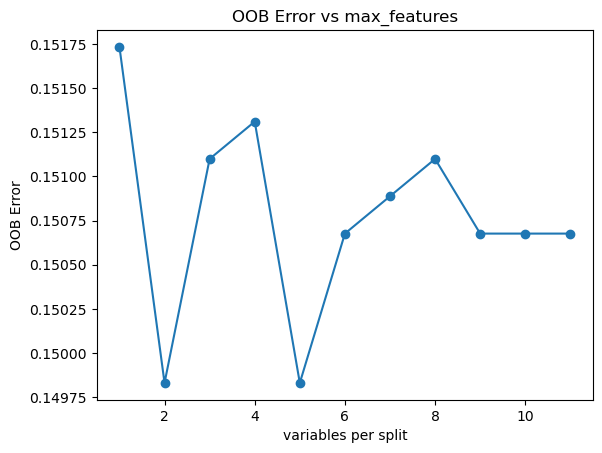

In [156]:
# Binary

# Create plot to find optimal max_features
rf_drug_use = RandomForestClassifier(n_estimators=200, class_weight="balanced", oob_score=True, random_state=1)
oob_errors = []

for n in range(1, 12):
    rf_drug_use.set_params(max_features=n)
    
    rf_drug_use.fit(X_train_bin, y_train_bin)
    oob_error = 1 - rf_drug_use.oob_score_
    oob_errors.append(oob_error)

# plot error vs max_features
plt.plot(range(1, 12), oob_errors, marker='o')
plt.xlabel("variables per split")
plt.ylabel("OOB Error")
plt.title("OOB Error vs max_features")
plt.show()

In [157]:
# Binary

# Fit random forest model
rf_drug_use = RandomForestClassifier(n_estimators=200, class_weight="balanced", max_features=2, random_state=1)
rf_drug_use.fit(X_train_bin, y_train_bin)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",2
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_tr

In [158]:
y_pred_rf = rf_drug_use.predict(X_test_bin)

conf_matrix_rf = confusion_matrix(y_test_bin, y_pred_rf)

print(f"Accuracy: {accuracy_score(y_test_bin, y_pred_rf)}")
print(f"\nConfusion Matrix:\n{conf_matrix_rf}")

precision_rf = conf_matrix_rf[1,1] / (conf_matrix_rf[1,1] + conf_matrix_rf[0,1])
print(f"\nPrecision: {precision_rf}")

recall_rf = conf_matrix_rf[1,1] / (conf_matrix_rf[1,1] + conf_matrix_rf[1,0])
print(f"\nRecall: {recall_rf}")

Accuracy: 0.8309740122543842

Confusion Matrix:
[[3399  582]
 [ 218  534]]

Precision: 0.478494623655914

Recall: 0.7101063829787234


<span style="color:green"> Accuracy score is good, but doesn't handle for skewed data as well. Confusion Matrix and precision indicate that when the model predicts a positive, it is correct only about half the time, which is decent but not great. It is decent, but not great. Recall score is better at 71% indicating the model is better at identifying actual positives and has relatively fewer false negatives. </span>

<span style="color:green"> Given the class imbalance, where the majority of observations are non-users, the model achieves strong recall for correctly identifying users. This indicates effective detection of the minority class, which is usually harder with imbalanced data. </span>

----------

## Q: Can demographic and social factors be used to predict the level of marijuana use among youth?

----------

In [159]:
# Multi-class

# Fit Gradient Boosting model
boost_drug_use = GradientBoostingClassifier(n_estimators=500, learning_rate=0.01, random_state=1)
boost_drug_use.fit(X_train_multi, y_train_multi)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.01
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",500
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``,

In [160]:
y_pred_boost = boost_drug_use.predict(X_test_multi)

conf_matrix_boost = confusion_matrix(y_test_multi, y_pred_boost)

print("\nConfusion Matrix:\n", confusion_matrix(y_test_multi, y_pred_boost))
print("\nClassification Report:\n", classification_report(y_test_multi, y_pred_boost))


Confusion Matrix:
 [[   0    0    3    0   90]
 [   0    0    1    1   69]
 [   0    0    0    0   95]
 [   0    0    3    4   92]
 [   1    0    2    2 4370]]

Classification Report:
               precision    recall  f1-score   support

           1       0.00      0.00      0.00        93
           2       0.00      0.00      0.00        71
           3       0.00      0.00      0.00        95
           4       0.57      0.04      0.08        99
           5       0.93      1.00      0.96      4375

    accuracy                           0.92      4733
   macro avg       0.30      0.21      0.21      4733
weighted avg       0.87      0.92      0.89      4733



c:\Users\Jgrab\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Jgrab\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Jgrab\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


<span style="color:green"> I started with an n_estimators value of 200, and although Gradient Boosting achieved high overall accuracy, the confusion matrix reveals that it primarily predicts non-users since that is the dominant class. This indicates that the model is not effectively distinguishing between different levels of marijuana use, likely due to severe class imbalance. </span>

<span style="color:green"> Increasing the number of trees to 500 led to slight improvements in minority class detection, but the model remains dominated by the majority class and struggles to accurately classify lower-frequency usage categories. </span>

----------

## Q: Among youth who use marijuana, can demographic and social factors predict the frequency of use over the past year?

----------

In [161]:
# Regression

# fit decision tree model
tree_drug_use = DecisionTreeRegressor(random_state = 1)
tree_drug_use.fit(X_train_reg, y_train_reg)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",1
,"max_le

In [162]:
tree_summary = export_text(tree_drug_use, feature_names=X_train_reg.columns.tolist())
print(tree_summary)

|--- TOBFLAG <= 0.50
|   |--- AVGGRADE <= 1.50
|   |   |--- ALCFLAG <= 0.50
|   |   |   |--- STNDSMJ <= 1.50
|   |   |   |   |--- INCOME <= 3.50
|   |   |   |   |   |--- TCHGJOB <= 1.50
|   |   |   |   |   |   |--- IFATHER <= 1.50
|   |   |   |   |   |   |   |--- value: [17.00]
|   |   |   |   |   |   |--- IFATHER >  1.50
|   |   |   |   |   |   |   |--- INCOME <= 1.50
|   |   |   |   |   |   |   |   |--- SCHFELT <= 1.50
|   |   |   |   |   |   |   |   |   |--- value: [46.00]
|   |   |   |   |   |   |   |   |--- SCHFELT >  1.50
|   |   |   |   |   |   |   |   |   |--- value: [43.00]
|   |   |   |   |   |   |   |--- INCOME >  1.50
|   |   |   |   |   |   |   |   |--- value: [69.00]
|   |   |   |   |   |--- TCHGJOB >  1.50
|   |   |   |   |   |   |--- INCOME <= 2.00
|   |   |   |   |   |   |   |--- value: [5.00]
|   |   |   |   |   |   |--- INCOME >  2.00
|   |   |   |   |   |   |   |--- value: [1.00]
|   |   |   |   |--- INCOME >  3.50
|   |   |   |   |   |--- IFATHER <= 1.50
|   |   | 

In [163]:
importances = pd.DataFrame({'feature_name': X_train_reg.columns, 'importance': tree_drug_use.feature_importances_})
importances = importances.sort_values('importance', ascending=False).reset_index(drop=True)
print(importances)

  feature_name  importance
0       INCOME    0.233072
1      ALCFLAG    0.116562
2      TOBFLAG    0.115233
3      IFATHER    0.113580
4      TCHGJOB    0.112824
5     AVGGRADE    0.112022
6      IMOTHER    0.097071
7      SCHFELT    0.053798
8      STNDSMJ    0.045838


<span style="color:green"> From the importance table, INCOME appears to be the most important predictor. </span>

In [164]:
# Calculate the accuracy of the decision tree on the test data
accuracy = tree_drug_use.score(X_test_reg, y_test_reg)
print("Accuracy: {:.2f}%".format(accuracy*100))

Accuracy: -45.37%


<span style="color:green"> Accuracy score is -45.37% which means this model is worse than a baseline model that predicts the mean for frequency of marijuana use over the past year. </span>

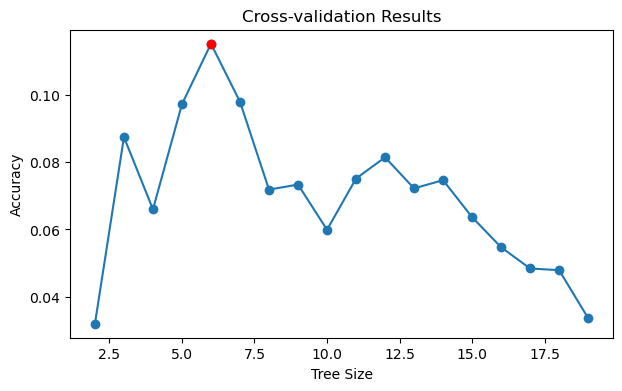

In [165]:
# cross-validation to determine optimal tree size
params = {'max_leaf_nodes': range(2, 20)}  
cv_drug_use = GridSearchCV(tree_drug_use, params, cv=20)
cv_drug_use.fit(X_train_reg, y_train_reg)
cv_results = cv_drug_use.cv_results_

# find the best score for max leaf nodes
best_size = cv_drug_use.best_params_['max_leaf_nodes']
best_score = cv_drug_use.best_score_

# plot results of cross-validation
plt.figure(figsize=(7, 4))
plt.plot(cv_results["param_max_leaf_nodes"].data, cv_results["mean_test_score"], 'o-')
plt.plot(best_size, best_score, 'ro-')
plt.xlabel('Tree Size')
plt.ylabel('Accuracy')
plt.title('Cross-validation Results');

In [166]:
# fit pruned decision tree model
pruned_tree_drug_use = DecisionTreeRegressor(max_leaf_nodes=best_size, random_state=1)
pruned_tree_drug_use.fit(X_train_reg, y_train_reg)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",1
,"max_le

In [167]:
pruned_tree_summary = export_text(pruned_tree_drug_use, feature_names=X_train_reg.columns.tolist())
print(pruned_tree_summary)

|--- TOBFLAG <= 0.50
|   |--- AVGGRADE <= 1.50
|   |   |--- ALCFLAG <= 0.50
|   |   |   |--- value: [45.90]
|   |   |--- ALCFLAG >  0.50
|   |   |   |--- value: [184.77]
|   |--- AVGGRADE >  1.50
|   |   |--- IMOTHER <= 1.50
|   |   |   |--- value: [42.99]
|   |   |--- IMOTHER >  1.50
|   |   |   |--- STNDSMJ <= 1.50
|   |   |   |   |--- value: [148.12]
|   |   |   |--- STNDSMJ >  1.50
|   |   |   |   |--- value: [19.40]
|--- TOBFLAG >  0.50
|   |--- value: [122.40]



In [168]:
importances_pruned = pd.DataFrame({'feature_name': X_train_reg.columns, 'importance': pruned_tree_drug_use.feature_importances_})
importances_pruned = importances_pruned.sort_values('importance', ascending=False).reset_index(drop=True)
print(importances_pruned)

  feature_name  importance
0      TOBFLAG    0.425006
1     AVGGRADE    0.261841
2      IMOTHER    0.115084
3      ALCFLAG    0.108393
4      STNDSMJ    0.089676
5      TCHGJOB    0.000000
6      IFATHER    0.000000
7       INCOME    0.000000
8      SCHFELT    0.000000


<span style="color:green"> After pruning the tree, tobacco useage flag and average grade appear to have become the most important predictors. </span>

In [169]:
# Calculate the accuracy of the pruned decision tree on the test data
accuracy = pruned_tree_drug_use.score(X_test_reg, y_test_reg)
print("Accuracy: {:.2f}%".format(accuracy*100))

Accuracy: -2.50%


<span style="color:green"> Pruning the tree improved the accuracy score significantly, but it still appears to be worse than a baseline model that predicts the mean. </span>

In [170]:
y_pred_tree = pruned_tree_drug_use.predict(X_test_reg)

# Calculate MSE
MSE = ((y_test_reg - pruned_tree_drug_use.predict(X_test_reg))**2).mean()
print(MSE)


12119.031680957878


<span style="color:green"> The regression model performed poorly, as indicated by the negative R^2 value, which means that it performed worse than predicting the mean outcome. This suggests that the available demographic and social features are not strong predictors of exact marijuana usage frequency. The extreme skewness in the target variable likely contribute to the model’s difficulty. </span>